In [1]:
import requests
from pprint import pprint
import matplotlib.pyplot as plt 
import time
import numpy as np
import math

In [28]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import pytz
pd.set_option('display.max_columns', 500) # number of columns to be displayed
pd.set_option('display.width', 1500)      # max table width to display
 
# establish connection to MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

timezone = pytz.timezone("Etc/UTC")
# create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
x = datetime.now()
utc_from = datetime(2021, 6, 15, tzinfo=timezone)
utc_to = datetime(x.year, x.month, x.day+1, tzinfo=timezone)
# rates = mt5.copy_rates_from("EURUSD", mt5.TIMEFRAME_M30, utc_from,75)
rates = mt5.copy_rates_range("EURUSD", mt5.TIMEFRAME_M30, utc_from, utc_to)

# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

rates_frame = pd.DataFrame(rates)
rates_frame = rates_frame.drop(['open', 'high', 'low','tick_volume', 'spread', 'real_volume'], axis=1)
# convert time in seconds into the datetime format
rates_frame['time']=pd.to_datetime(rates_frame['time'], unit='s')
rates_frame = rates_frame.set_index('time')

EMA = rates_frame['close'].ewm(span=100, adjust=False).mean()
DEMA = 2*EMA - EMA.ewm(span=100, adjust=False).mean()
rates_frame['dma'] = DEMA
print(len(rates_frame['close']))
rates_frame['ll'] = rates_frame['close'].rolling(window=100).mean()
# print(rates_frame.head())
# print(rates_frame[98:150])

447


In [29]:
rates_frame.tail()

,close,dma,ll
time,,,
2021-06-28 08:30:00,1.19258,1.193676,1.193652
2021-06-28 09:00:00,1.19319,1.193661,1.193660
2021-06-28 09:30:00,1.19307,1.193641,1.193666
2021-06-28 10:00:00,1.19382,1.193651,1.193681
2021-06-28 10:30:00,1.19412,1.193673,1.193699


In [37]:
c = 0
buy = []
sell = []
if rates_frame.iloc[-2].close > rates_frame.iloc[-1].ll:
    print("buy")
elif rates_frame.iloc[-2].close < rates_frame.iloc[-1].ll:
    print("sell")

    

buy


In [144]:
for i, j in rates_frame_1.iterrows():
    if not math.isnan(j.ll):
        print(j)
        break

close    110.0710
ll       110.0771
Name: 2021-06-15 09:15:00, dtype: float64


In [9]:
rates_frame.loc["2021-06-25 18:30:00":, :]

,close,ll
time,,
2021-06-25 18:30:00,1.19398,1.193665
2021-06-25 19:00:00,1.19330,1.193639
2021-06-25 19:30:00,1.19362,1.193628


In [8]:
c = 0
buy = []
sell = []
df = rates_frame.iloc[:]
for index, row in df.iterrows():
    try:
        if row['close'] > row['ll'] and rates_frame.iloc[index+1]['close'] < row['ll']:
#             print(rates_frame.iloc[index]['time'])
#             print(row['close'], row['ll'])
            a = datetime.now() - rates_frame.iloc[index]['time']
            if a.seconds <= 14000:
                c+= 1
                buy.append(rates_frame.iloc[index]['close'])
            else:
                buy.append(np.nan)
                
        elif row['close'] < row['ll'] and rates_frame.iloc[index+1]['close'] > row['ll']:
#             print(rates_frame.iloc[index]['time'])
#             print(row['close'], row['ll'])
            a = datetime.now() - rates_frame.iloc[index]['time']
            if a.seconds <= 14000:
                c += 1
                buy.append(rates_frame.iloc[index]['close'])
            else:
                buy.append(np.nan)
        else:
            buy.append(np.nan)
                
    except:
        pass
buy.append(np.nan)
print(len(buy))
rates_frame['Buy'] = buy
# if c:
#     telegram_bot_sendtext("EURUSD Alert")
    

761


In [5]:
rates_frameA = rates_frame.loc["2021-06-24 17:30:00":,:]
# rates_frameB = rates_frame_1.loc["2021-06-24 17:30:00":,:]

NameError: name 'rates_frame_1' is not defined

In [39]:
a = []
for i in rates_frameB.iterrows():
    a.append(i[0]-pd.Timedelta(minutes=25))

rates_frameB['ind'] = a


<ipython-input-39-e37e4cc78653>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rates_frameB['ind'] = a


In [40]:
rates_frameB = rates_frameB.set_index('ind')

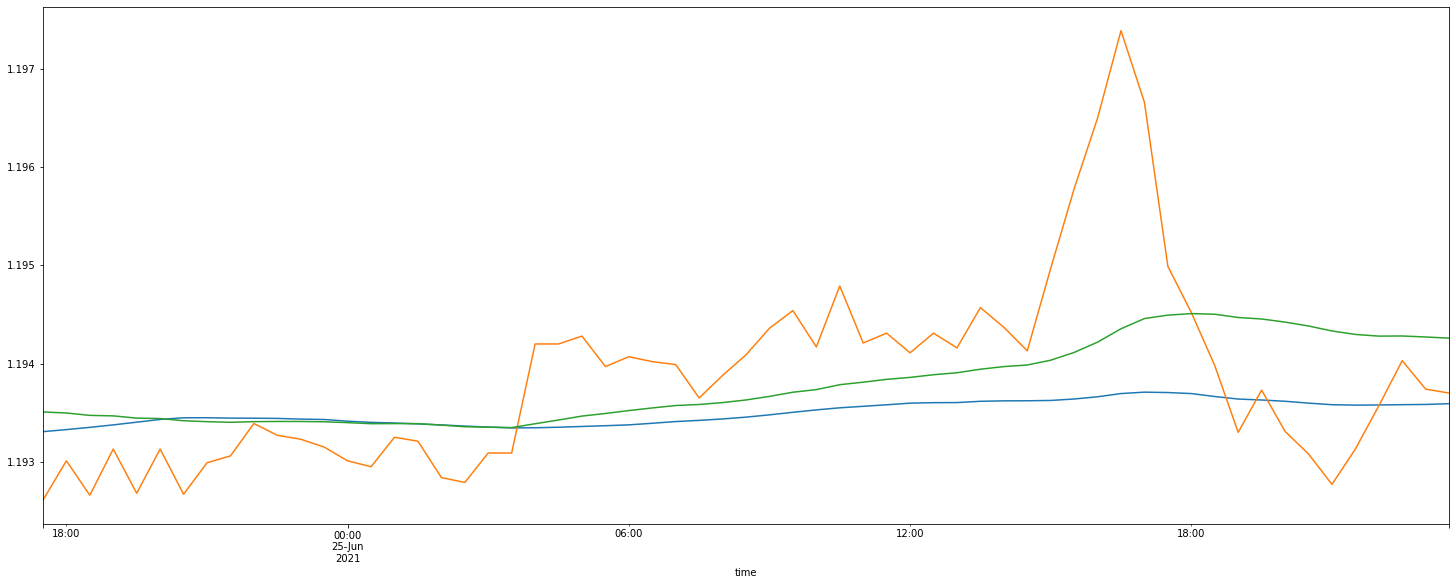

In [8]:
column_list = ['ll', 'close']
plt.figure(figsize=(25.2,9.5))
rates_frameA['ll'].plot()
rates_frameA['close'].plot()
# rates_frame_1['close'].plot()
rates_frameA['dma'].plot()
plt.show();

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

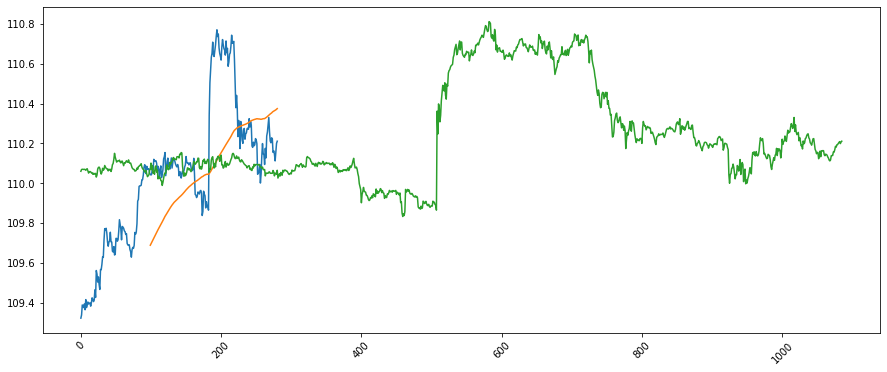

In [73]:
rates_frame['close'].plot(figsize=(15,6))
# rates_frame['ll'] = rates_frame['close'].rolling(window=100).mean()
rates_frame['ll'].plot()
rates_frame_1['close'].plot()

# plt.scatter(rates_frame['Buy'], color = 'green', label='Buy Signal', marker = '^', alpha = 1)
# rates_frame['Buy'].plot(color = 'red', label='Buy Signal', marker = '^', alpha = 1)
# plt.plot( l[200:-100], 'r').rolling(window=100).

plt.xticks(rotation = 45)
# plt.ylim(1.19320,1.19350)
# plt.autoscale()

In [33]:
print(rates_frame['time'][:100])

0    2021-05-28 00:00:00
1    2021-05-28 00:30:00
2    2021-05-28 01:00:00
3    2021-05-28 01:30:00
4    2021-05-28 02:00:00
             ...        
95   2021-05-31 23:30:00
96   2021-06-01 00:00:00
97   2021-06-01 00:30:00
98   2021-06-01 01:00:00
99   2021-06-01 01:30:00
Name: time, Length: 100, dtype: datetime64[ns]


In [44]:
from datetime import datetime
import MetaTrader5 as mt5
import pandas as pd
import pytz
pd.set_option('display.max_columns', 500) # number of columns to be displayed
pd.set_option('display.width', 1500)      # max table width to display
 
# establish connection to MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()

timezone = pytz.timezone("Etc/UTC")
# create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
x = datetime.now()
utc_from = datetime(2021, 6, 15, tzinfo=timezone)
utc_to = datetime(x.year, x.month, x.day+1, tzinfo=timezone)
# rates = mt5.copy_rates_from("EURUSD", mt5.TIMEFRAME_M30, utc_from,75)
# rates = mt5.copy_rates_range("USDJPY", mt5.TIMEFRAME_M30, utc_from, utc_to)
#Temporay line
rates = mt5.copy_rates_range("EURUSD", mt5.TIMEFRAME_M5, utc_from, utc_to)
 
# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

rates_frame_1 = pd.DataFrame(rates)
rates_frame_1 = rates_frame_1.drop(['open', 'high', 'low','tick_volume', 'spread', 'real_volume'], axis=1)

# convert time in seconds into the datetime format
rates_frame_1['time']=pd.to_datetime(rates_frame_1['time'], unit='s')
rates_frame_1 = rates_frame_1.set_index('time')
a = []
for i in rates_frame_1.iterrows():
    a.append(i[0]-pd.Timedelta(minutes=25))

rates_frame_1['ind'] = a

rates_frame_1 = rates_frame_1.set_index('ind')

print(len(rates_frame_1['close']))
rates_frame_1['ll'] = rates_frame_1['close'].rolling(window=100).mean()
# print(rates_frame.head())
# print(rates_frame_1[99:150])

2490


In [43]:
def DEMA(data, time_period, column):
    #Calculate the Exponential Moving Average for some time_period (in days)
    EMA = data[column].ewm(span=time_period, adjust=False).mean()
    #Calculate the DEMA
    DEMA = 2*EMA - EMA.ewm(span=time_period, adjust=False).mean()
    return DEMA

,close,ll
time,,
2021-06-25 18:30:00,1.19398,1.193665
2021-06-25 19:00:00,1.19330,1.193639
2021-06-25 19:30:00,1.19373,1.193629
2021-06-25 20:00:00,1.19331,1.193617
2021-06-25 20:30:00,1.19324,1.193599
